In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
X_test = X_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(64, (3, 3), activation='relu'))


model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("CNN Training Shuru... (Thoda time lag sakta hai)")
model.fit(X_train, y_train, epochs=5)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Training Shuru... (Thoda time lag sakta hai)
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.8961 - loss: 0.3324
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9853 - loss: 0.0495
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9897 - loss: 0.0322
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9932 - loss: 0.0222
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9941 - loss: 0.0183


Apni '6' wali file upload karein:


Saving Untitled5.png to Untitled5.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


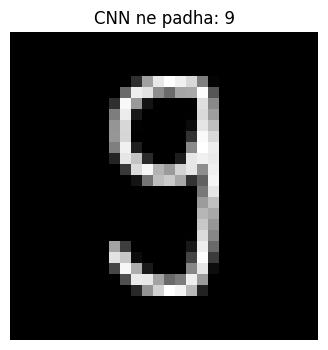

CNN Prediction: 9


In [ ]:
import numpy as np
from google.colab import files
from PIL import Image, ImageOps

print("Apni '6' wali file upload karein:")
uploaded = files.upload()

for fn in uploaded.keys():

    img = Image.open(fn).convert('L')
    img = ImageOps.invert(img)


    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)

    # Resize and Center
    img.thumbnail((20, 20))
    new_img = Image.new('L', (28, 28), color=0)
    width, height = img.size
    left = (28 - width) // 2
    top = (28 - height) // 2
    new_img.paste(img, (left, top))

    # Prepare for CNN (Reshape to 28, 28, 1)
    img_array = np.array(new_img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1) # <--- CNN ke liye change

    # Prediction
    prediction = model.predict(img_array)
    predicted_digit = np.argmax(prediction)

    # Show Result
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[0].reshape(28, 28), cmap='gray')
    plt.title(f"CNN ne padha: {predicted_digit}")
    plt.axis('off')
    plt.show()

    print(f"CNN Prediction: {predicted_digit}")